In [80]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
from sklearn.preprocessing import StandardScaler

In [81]:
df=pd.read_csv("linear - Sheet1.csv")
df

,House_ID,Area_sqft,Bedrooms,Bathrooms,Age_of_House,Distance_to_City (km),Parking,Floor,Nearby_Schools,Crime_Rate,House_Price (₹ Lakhs)
0,H001,800,2,1,15,12,1,1,2,4,42
1,H002,950,2,2,10,10,1,2,3,3,50
2,H003,1100,3,2,8,8,1,3,4,2,60
3,H004,1250,3,2,6,7,1,4,5,2,68
4,H005,1400,3,3,5,6,2,5,5,1,78
5,H006,1600,4,3,4,5,2,6,5,1,90
6,H007,1750,4,3,3,4,2,7,5,1,100
7,H008,1900,4,4,2,3,2,8,5,1,112
8,H009,2100,5,4,2,2,2,9,5,1,125
9,H010,2300,5,4,1,2,2,10,5,1,138


In [82]:
df.isnull().sum()

House_ID                 0
Area_sqft                0
Bedrooms                 0
Bathrooms                0
Age_of_House             0
Distance_to_City (km)    0
Parking                  0
Floor                    0
Nearby_Schools           0
Crime_Rate               0
House_Price (₹ Lakhs)    0
dtype: int64

In [83]:
df.head()

,House_ID,Area_sqft,Bedrooms,Bathrooms,Age_of_House,Distance_to_City (km),Parking,Floor,Nearby_Schools,Crime_Rate,House_Price (₹ Lakhs)
0,H001,800,2,1,15,12,1,1,2,4,42
1,H002,950,2,2,10,10,1,2,3,3,50
2,H003,1100,3,2,8,8,1,3,4,2,60
3,H004,1250,3,2,6,7,1,4,5,2,68
4,H005,1400,3,3,5,6,2,5,5,1,78


In [84]:
df.describe()

,Area_sqft,Bedrooms,Bathrooms,Age_of_House,Distance_to_City (km),Parking,Floor,Nearby_Schools,Crime_Rate,House_Price (₹ Lakhs)
count,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000
mean,1578.333333,3.600000,2.966667,5.800000,6.033333,1.633333,5.666667,4.433333,1.866667,89.866667
std,490.018179,1.037238,1.066200,4.566746,3.681111,0.490133,2.795727,0.935261,1.166585,32.218792
min,800.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000,40.000000
25%,1162.500000,3.000000,2.000000,2.000000,3.000000,1.000000,3.250000,4.000000,1.000000,63.000000
50%,1575.000000,4.000000,3.000000,4.500000,5.000000,2.000000,6.000000,5.000000,1.000000,89.000000
75%,1937.500000,4.000000,4.000000,8.000000,8.000000,2.000000,8.000000,5.000000,2.000000,115.000000
max,2500.000000,5.000000,5.000000,18.000000,15.000000,2.000000,10.000000,5.000000,5.000000,150.000000


In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   House_ID               30 non-null     object
 1   Area_sqft              30 non-null     int64 
 2   Bedrooms               30 non-null     int64 
 3   Bathrooms              30 non-null     int64 
 4   Age_of_House           30 non-null     int64 
 5   Distance_to_City (km)  30 non-null     int64 
 6   Parking                30 non-null     int64 
 7   Floor                  30 non-null     int64 
 8   Nearby_Schools         30 non-null     int64 
 9   Crime_Rate             30 non-null     int64 
 10  House_Price (₹ Lakhs)  30 non-null     int64 
dtypes: int64(10), object(1)
memory usage: 2.7+ KB


In [86]:
df.duplicated().sum()

np.int64(0)

In [87]:
df.shape

(30, 11)

<function matplotlib.pyplot.show(close=None, block=None)>

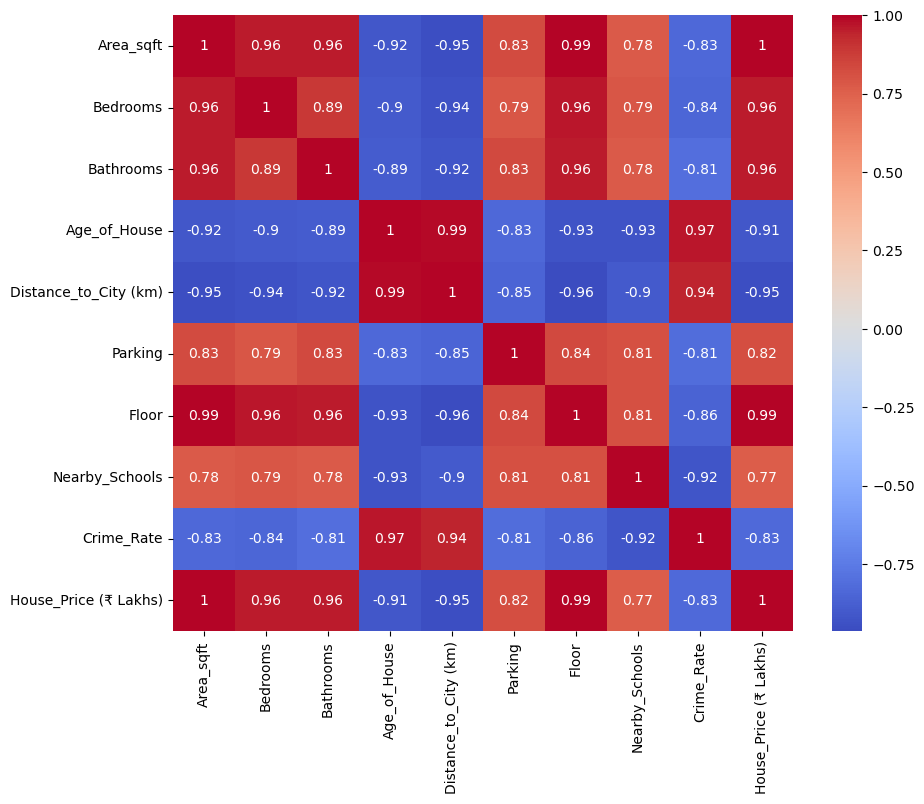

In [88]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="coolwarm")
plt.show

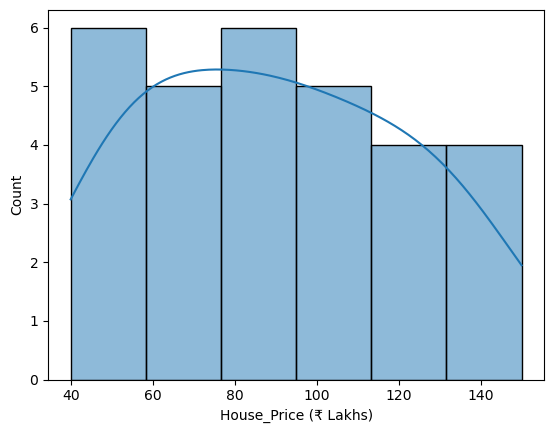

In [89]:
sns.histplot(df["House_Price (₹ Lakhs)"],kde=True)
plt.show()


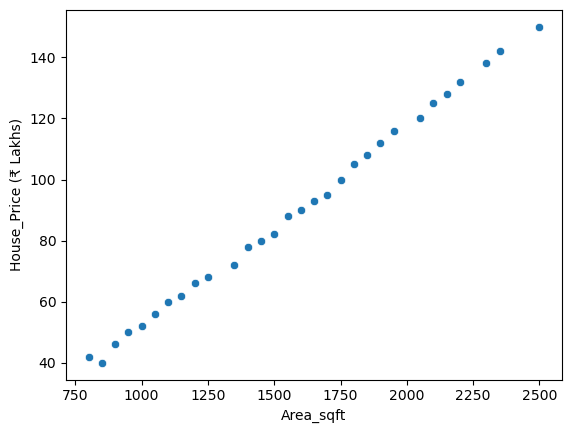

In [90]:
sns.scatterplot(x="Area_sqft",y="House_Price (₹ Lakhs)",data=df)
plt.show()

In [91]:
df=df.drop("House_ID",axis=1)
df

,Area_sqft,Bedrooms,Bathrooms,Age_of_House,Distance_to_City (km),Parking,Floor,Nearby_Schools,Crime_Rate,House_Price (₹ Lakhs)
0,800,2,1,15,12,1,1,2,4,42
1,950,2,2,10,10,1,2,3,3,50
2,1100,3,2,8,8,1,3,4,2,60
3,1250,3,2,6,7,1,4,5,2,68
4,1400,3,3,5,6,2,5,5,1,78
5,1600,4,3,4,5,2,6,5,1,90
6,1750,4,3,3,4,2,7,5,1,100
7,1900,4,4,2,3,2,8,5,1,112
8,2100,5,4,2,2,2,9,5,1,125
9,2300,5,4,1,2,2,10,5,1,138


In [92]:
X=df.drop("House_Price (₹ Lakhs)",axis=1)
y=df["House_Price (₹ Lakhs)"]

In [93]:
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42)

In [94]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [95]:
model=LinearRegression()


In [96]:
model.fit(X_train,y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [97]:
y_pred=model.predict(X_test)

In [98]:
print("mean_squared_error:",mean_squared_error(y_test,y_pred))
print("mean_absolute_error:",mean_absolute_error(y_test,y_pred))
print("r2_score:",r2_score(y_test,y_pred))

mean_squared_error: 0.598772088401183
mean_absolute_error: 0.7242622762168173
r2_score: 0.9987989862278559


In [99]:
# predicting house prices
new_house=[[1800, 3, 2, 4, 5, 6, 3, 2, 2]]
new_house_scaled=scaler.transform(new_house)
prediction=model.predict(new_house_scaled)
print("house price:",prediction[0])

house price: 92.73938566022957


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
